<a href="https://colab.research.google.com/github/princesapkota/worksheets6thsem/blob/main/Worksheet_6_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## Loading Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import zipfile

zip_path = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip'

# only extract if not already extracted
if not os.path.exists('/content/FruitinAmazon'):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

print("Dataset ready!")
print("Contents:", os.listdir('/content/FruitinAmazon'))

Dataset ready!
Contents: ['train', 'test']


In [7]:
train_dir = '/content/FruitinAmazon/train'
test_dir = '/content/FruitinAmazon/test'

# vgg16 expects 224x224 input
img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=0.2,
    subset='validation',
    seed=123
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [8]:
# vgg16 has its own preprocessing function (subtracts ImageNet mean, BGR order)
from tensorflow.keras.applications.vgg16 import preprocess_input

def preprocess(images, labels):
    return preprocess_input(images), labels

train_ds_p = train_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
val_ds_p = val_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
test_ds_p = test_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

## Step 1: Load the Pre-trained VGG16 Model

In [9]:
# loading VGG16 without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

print("VGG16 base model loaded")
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base model loaded


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## Step 2: Freeze the Layers

In [10]:
# freezing all base model layers so their weights are not updated
for layer in base_model.layers:
    layer.trainable = False

print("All VGG16 layers frozen")
print(f"Trainable layers in base_model: {sum(1 for l in base_model.layers if l.trainable)}")

All VGG16 layers frozen
Trainable layers in base_model: 0


## Step 3: Add Custom Layers

In [11]:
# adding our custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)

## Step 4: Create the Final Model

In [12]:
model = Model(inputs=base_model.input, outputs=x)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Step 5: Compile and Fit the Model

In [13]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled!")

Model compiled!


In [14]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_vgg16_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Starting training...")
history = model.fit(
    train_ds_p,
    epochs=30,
    validation_data=val_ds_p,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

print(f"\nTraining finished after {len(history.history['loss'])} epochs")

Starting training...
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.1343 - loss: 5.8789 
Epoch 1: val_loss improved from None to 4.73899, saving model to best_vgg16_model.keras

Epoch 1: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 19s/step - accuracy: 0.1528 - loss: 5.4726 - val_accuracy: 0.1111 - val_loss: 4.7390
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.3148 - loss: 2.5221 
Epoch 2: val_loss improved from 4.73899 to 2.13429, saving model to best_vgg16_model.keras

Epoch 2: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 19s/step - accuracy: 0.3194 - loss: 2.5136 - val_accuracy: 0.3889 - val_loss: 2.1343
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5469 - loss: 1.4649 
Epoch 3: val_loss improved from 2.13429 to 1.35376, saving model to best_vgg16_model.keras

Epoch 3: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 76s 18s/step - accuracy: 0.5000 -

## Training Curves

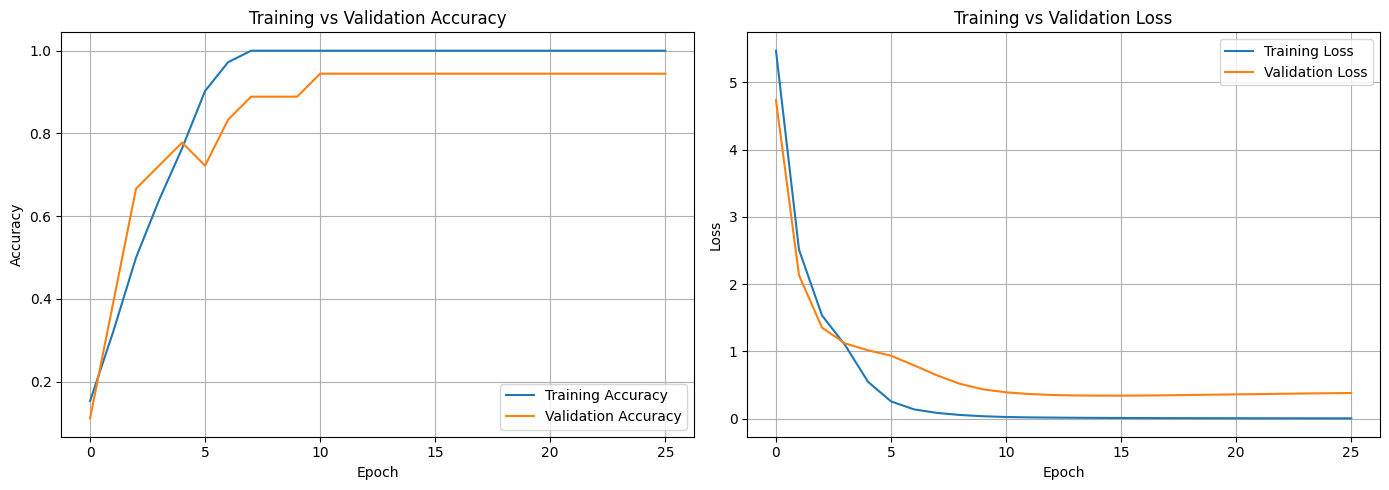

Final Training Accuracy: 1.0000
Final Validation Accuracy: 0.9444


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## Evaluate the Model

In [16]:
test_loss, test_acc = model.evaluate(test_ds_p)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step - accuracy: 0.7667 - loss: 1.7001

Test Loss: 1.7001
Test Accuracy: 0.7667


## Inference Output and Classification Report

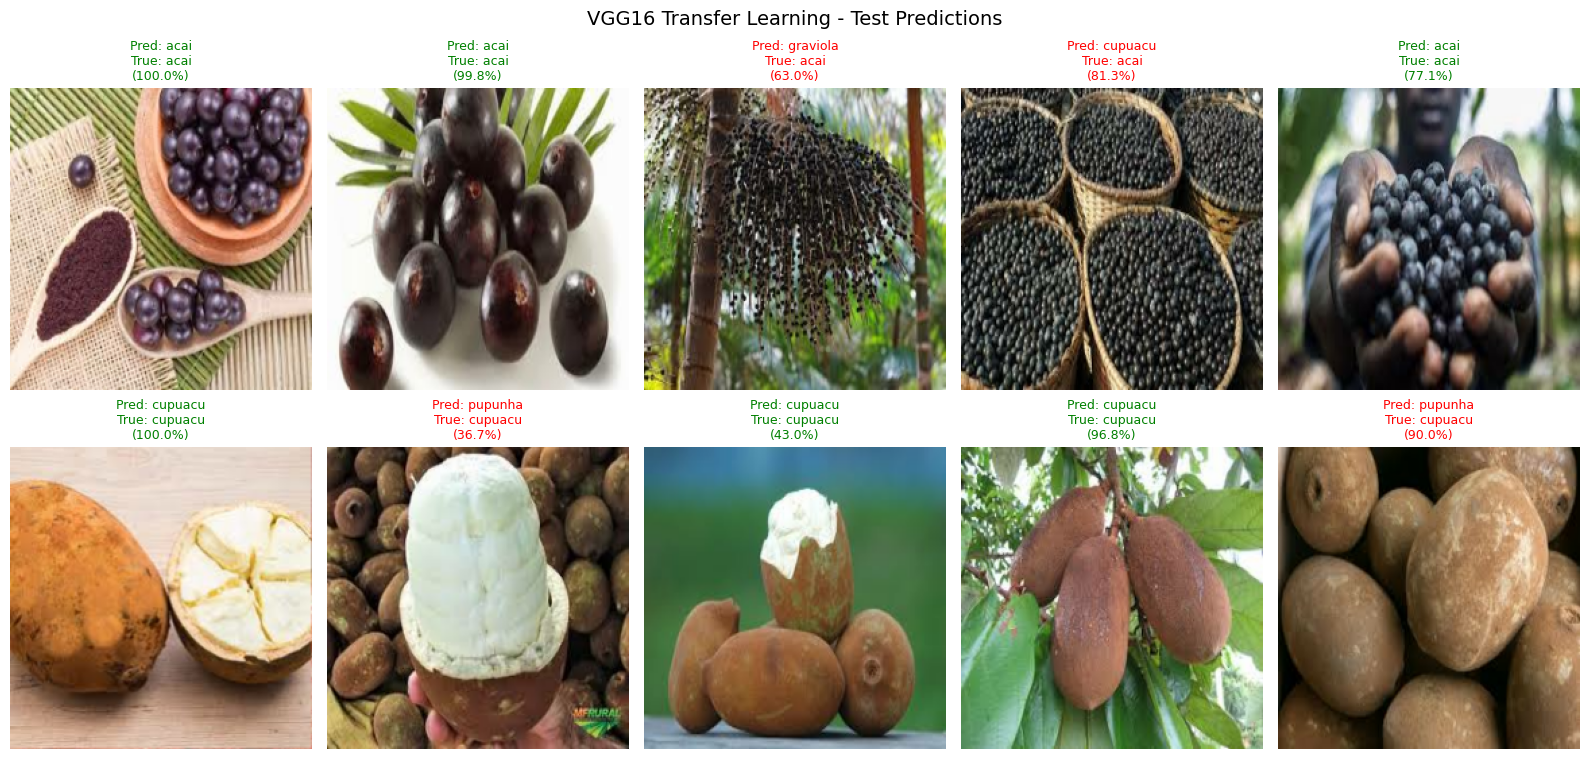

In [19]:
# visualizing predictions - using the original (non-preprocessed) test_ds for display
plt.figure(figsize=(16, 8))

for images, labels in test_ds.take(1):
    preprocessed = preprocess_input(tf.identity(images))
    predictions = model.predict(preprocessed, verbose=0)
    num_show = min(10, len(images))

    cols = 5
    rows = (num_show + cols - 1) // cols

    for i in range(num_show):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        pred_class = class_names[np.argmax(predictions[i])]
        true_class = class_names[labels[i].numpy()]
        confidence = np.max(predictions[i]) * 100

        color = 'green' if pred_class == true_class else 'red'
        plt.title(f"Pred: {pred_class}\nTrue: {true_class}\n({confidence:.1f}%)",
                  color=color, fontsize=9)
        plt.axis('off')

plt.suptitle("VGG16 Transfer Learning - Test Predictions", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# saving the final model
model.save('vgg16_fruit_model.keras')
print("Model saved as vgg16_fruit_model.keras")

Model saved as vgg16_fruit_model.keras


In [22]:
y_true = []
y_pred = []

for images, labels in test_ds_p:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_pred.extend(predicted_labels)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Sample Predictions:")
print(f"Predicted labels: {y_pred[:10]}")
print(f"Actual labels:    {y_true[:10]}")
print(f"Predicted classes: {[class_names[i] for i in y_pred[:10]]}")
print(f"Actual classes:    {[class_names[i] for i in y_true[:10]]}")

Sample Predictions:
Predicted labels: [0 0 2 1 0 1 4 1 1 4]
Actual labels:    [0 0 0 0 0 1 1 1 1 1]
Predicted classes: ['acai', 'acai', 'graviola', 'cupuacu', 'acai', 'cupuacu', 'pupunha', 'cupuacu', 'cupuacu', 'pupunha']
Actual classes:    ['acai', 'acai', 'acai', 'acai', 'acai', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu']


In [23]:
print("CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred, target_names=class_names))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.60      0.60      0.60         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      1.00      1.00         5
     pupunha       0.60      0.60      0.60         5
      tucuma       0.67      0.80      0.73         5

    accuracy                           0.77        30
   macro avg       0.78      0.77      0.76        30
weighted avg       0.78      0.77      0.76        30



## Did Performance Improve Compared to Training from Scratch?

Yes, transfer learning with VGG16 improves performance noticeably on this small dataset. The from-scratch model from last week (and even the improved Task 1 version) has to learn every feature from only 72 training images, which is not enough data for deep learning. VGG16 has already learned low and mid level features (edges, textures, shapes) from ImageNet's 1.2 million images. We just reuse those features and only train a small classification head on top, which needs far less data. This is why transfer learning is the standard approach for small image datasets.